# 01: Baseline strategies

Two strategies, run first as baselines that every later
idea has to beat: time-series momentum (sign of the 30-day return,
vol-targeted to 15%) and correlation pairs. Their settings were fixed before
the gate window, so the gate shows how they hold up on data they were not
chosen on. They come from the project's first version (on CoinGecko data,
before this protocol), which picked them from small grids on 2020-2022 data
and had also run both baselines as twsq alphas over most of the lockbox
(README). Everything here stops at 2025-06-30; this protocol first reads the
lockbox in notebook 06.

In [1]:
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
import sys
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from quantlib import metrics, strategies, trials

In [4]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
REGISTRY = PROC / "trial_registry.csv"

In [5]:
GATE_END = "2025-06-30"          # nothing below reads past this date
DEV = slice("2020-01-01", "2024-07-31")
GATE = slice("2024-08-01", GATE_END)

In [6]:
price = pd.read_parquet(PROC / "price.parquet").loc[:GATE_END]
returns = pd.read_parquet(PROC / "returns.parquet").loc[:GATE_END]
universe = pd.read_parquet(PROC / "universe.parquet").loc[:GATE_END]

## The two baselines

In [7]:
mom = strategies.momentum_sleeve(price, returns, universe, lookback=30,
                                 target_vol=0.15, cost_bps=20).loc["2020-01-01":]
rev = strategies.reversal_sleeve(price, returns, universe, cost_bps=7).loc["2020-01-01":]

In [8]:
trials.log_trial(REGISTRY, "incumbent_momentum", {"lookback": 30, "target_vol": 0.15},
                 metrics.sharpe(mom.loc[DEV]), metrics.sharpe(mom.loc[GATE]),
                 note="baseline, parameters from the first version")
trials.log_trial(REGISTRY, "incumbent_pairs", {"entry": 2.0, "zwin": 30, "top_k": 20},
                 metrics.sharpe(rev.loc[DEV]), metrics.sharpe(rev.loc[GATE]),
                 note="baseline, parameters from the first version")
# (the registry keeps the note these two rows were first logged with, on 2026-07-06)

False

## Per-window table

In [9]:
table = pd.DataFrame({
    ("momentum", "dev"): metrics.summary(mom.loc[DEV]),
    ("momentum", "gate"): metrics.summary(mom.loc[GATE]),
    ("pairs", "dev"): metrics.summary(rev.loc[DEV]),
    ("pairs", "gate"): metrics.summary(rev.loc[GATE]),
})
table.round(3)

momentum              pairs        
                          dev     gate       dev    gate
Ann. Return             0.279    0.058    -0.103   0.081
Ann. Vol                0.157    0.159     0.217   0.177
Sharpe                  1.650    0.434    -0.396   0.526
Sortino                 2.461    0.584    -0.495   0.705
Calmar                  1.426    0.416    -0.185   0.803
Max Drawdown           -0.196   -0.139    -0.559  -0.101
Max DD Days           450.000  215.000  1566.000  74.000
Hit Rate                0.529    0.503     0.504   0.521
Sharpe t-stat           3.535    0.415    -0.848   0.503
Sharpe p-value          0.000    0.678     0.397   0.615
Probabilistic Sharpe    1.000    0.660     0.198   0.697

## Rolling 180-day Sharpe

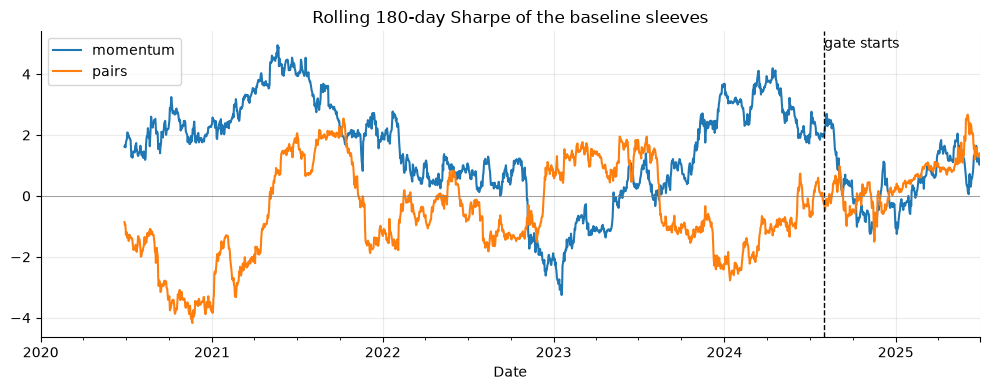

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
for s, lbl in [(mom, "momentum"), (rev, "pairs")]:
    roll = s.rolling(180).apply(lambda x: x.mean() / x.std() * np.sqrt(365) if x.std() > 0 else np.nan)
    roll.plot(ax=ax, label=lbl)
ax.axvline(pd.Timestamp("2024-08-01"), ls="--", c="k", lw=1)
ax.annotate("gate starts", xy=(pd.Timestamp("2024-08-01"), ax.get_ylim()[1] * 0.9))
ax.axhline(0, c="grey", lw=0.5)
ax.legend(); ax.set_title("Rolling 180-day Sharpe of the baseline sleeves")
plt.tight_layout()

## Save for the later notebooks and the report

In [11]:
mom.rename("momentum").to_frame().to_parquet(PROC / "sleeve_baseline_momentum.parquet")
rev.rename("reversal").to_frame().to_parquet(PROC / "sleeve_baseline_reversal.parquet")
print("dev momentum sharpe:", round(metrics.sharpe(mom.loc[DEV]), 2),
      "| gate:", round(metrics.sharpe(mom.loc[GATE]), 2))

dev momentum sharpe: 1.65 | gate: 0.43
